<a href="https://colab.research.google.com/github/marlon-domingues/Darwini/blob/main/Proje%C3%A7%C3%A3o%20financeira%20COTEM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# prompt: importe as bibliotecas usuais

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
tempo_em_anos = 5
meses = [i for i in range(tempo_em_anos * 12)]
qtd_meses = len(meses)

preco_aluguel_inicial = 800
preco_aluguel_final = 4800

inicio_do_aumento = 0

preco = [preco_aluguel_inicial for i in range(int(inicio_do_aumento * 12))]

it = int((tempo_em_anos - inicio_do_aumento) * 12)
for i in range(it):
  preco.append(preco_aluguel_inicial * (1 - i/it) + preco_aluguel_final * (i/it))




In [5]:
quantidade_de_maquinas_inicial = 0
quantidade_de_maquinas_final = 300



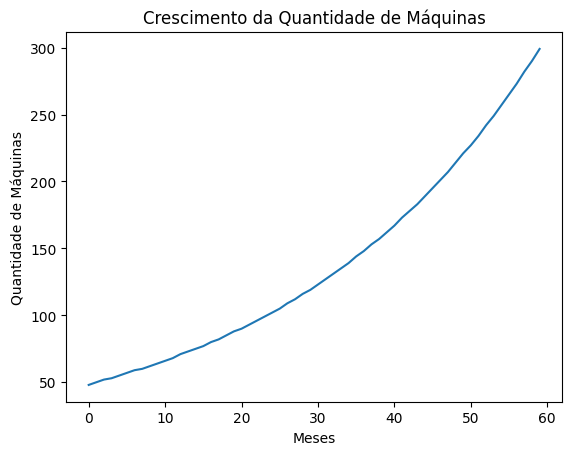

In [6]:
# prompt: #faca uma serie que interpola esses dois valores, com base na serie meses usando crescendo de maneira logaritmca
# #plote a serie

quantidade_de_maquinas = np.interp(meses, [0, qtd_meses-1], [quantidade_de_maquinas_inicial, quantidade_de_maquinas_final])
quantidade_de_maquinas = np.exp(np.linspace(np.log(50), np.log(quantidade_de_maquinas_final+1), qtd_meses)).astype(int) -1

plt.plot(meses, quantidade_de_maquinas)
plt.xlabel('Meses')
plt.ylabel('Quantidade de Máquinas')
plt.title('Crescimento da Quantidade de Máquinas')
plt.show()


In [7]:
custo_maquina = 20000
custo_manutencao = 2000


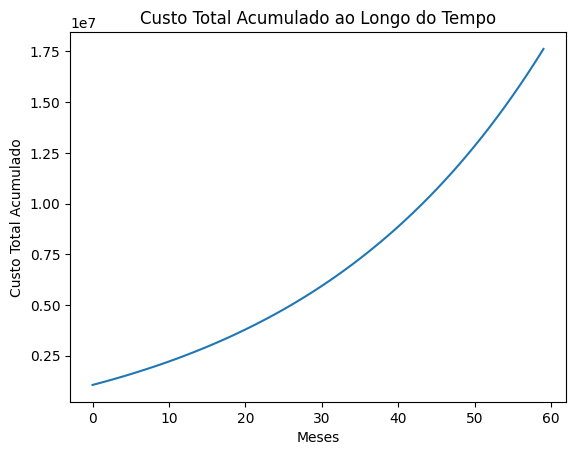

In [8]:
# prompt: me dê uma serie de custo total acumulado, consideranto a quantidade mensal de maquinas, o custo de montagem de cada maquine a o custo de manutenção mensal, plote a serie final

custo_total_acumulado = []
custo_total = 0

for i in range(qtd_meses):
  custo_mensal = quantidade_de_maquinas[i] * custo_manutencao
  if i == 0:
    custo_mensal += quantidade_de_maquinas[i] * custo_maquina
  custo_total += custo_mensal
  custo_total_acumulado.append(custo_total)

plt.plot(meses, custo_total_acumulado)
plt.xlabel('Meses')
plt.ylabel('Custo Total Acumulado')
plt.title('Custo Total Acumulado ao Longo do Tempo')
plt.show()


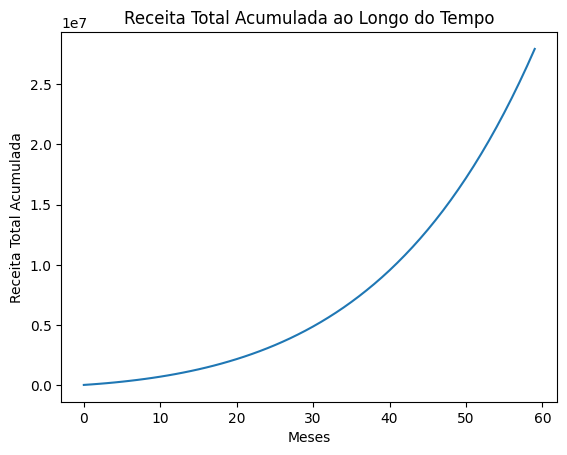

In [9]:
# prompt: Me dê uma série com os valores obtidos a partir do aluguel das máquinas de acordo com o passar dos anos, plote os resultados

receita_total_acumulada = []
receita_total = 0

for i in range(qtd_meses):
  receita_mensal = quantidade_de_maquinas[i] * preco[i]
  receita_total += receita_mensal
  receita_total_acumulada.append(receita_total)

plt.plot(meses, receita_total_acumulada)
plt.xlabel('Meses')
plt.ylabel('Receita Total Acumulada')
plt.title('Receita Total Acumulada ao Longo do Tempo')
plt.show()


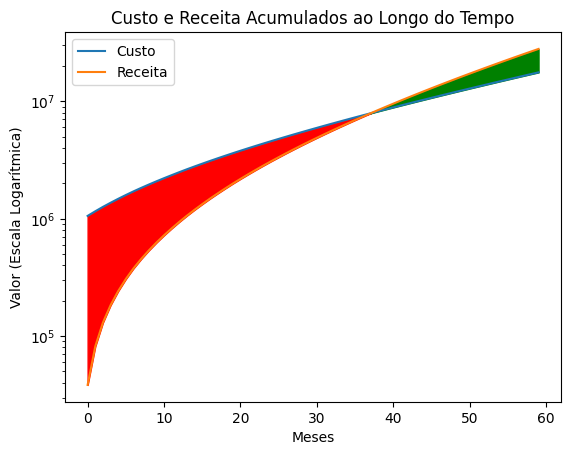

In [10]:
# prompt: Gere um gráfico com duas curvas, a de custos e de receitas, a area entre custo e receita pinte de vermelho, a area entre receita e custo pinte de verde, coloque o eixo y do gŕafico em escala logaritmica

where_1 = [custo_total_acumulado[i] < receita_total_acumulada[i] for i in range(qtd_meses)]
where_2 = [custo_total_acumulado[i] >= receita_total_acumulada[i] for i in range(qtd_meses)]


plt.plot(meses, custo_total_acumulado, label='Custo')
plt.plot(meses, receita_total_acumulada, label='Receita')
plt.xlabel('Meses')
plt.ylabel('Valor (Escala Logarítmica)')
plt.title('Custo e Receita Acumulados ao Longo do Tempo')
plt.yscale('log')

# Preenchendo áreas entre as curvas
plt.fill_between(meses, custo_total_acumulado, receita_total_acumulada, where=where_1, color='green', interpolate=True)
plt.fill_between(meses, custo_total_acumulado, receita_total_acumulada, where=where_2, color='red', interpolate=True)

plt.legend()
plt.show()


In [11]:
metro_quadrado_diario = 100
dias_uteis_no_mes = 22
salario_operador = 8000


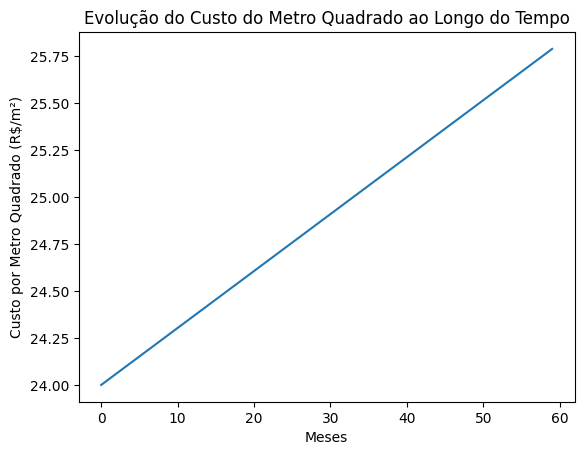

In [12]:
# prompt: Levando em consideração o preço de aluguel mensal da máquina e sua evolução, faça um gráfico da evolução do custo do metro quadrado

custo_metro_quadrado_mensal = [20.0 + (preco[i] + salario_operador) /  (metro_quadrado_diario * dias_uteis_no_mes) for i in range(qtd_meses)]

plt.plot(meses, custo_metro_quadrado_mensal)
plt.xlabel('Meses')
plt.ylabel('Custo por Metro Quadrado (R$/m²)')
plt.title('Evolução do Custo do Metro Quadrado ao Longo do Tempo')
plt.show()


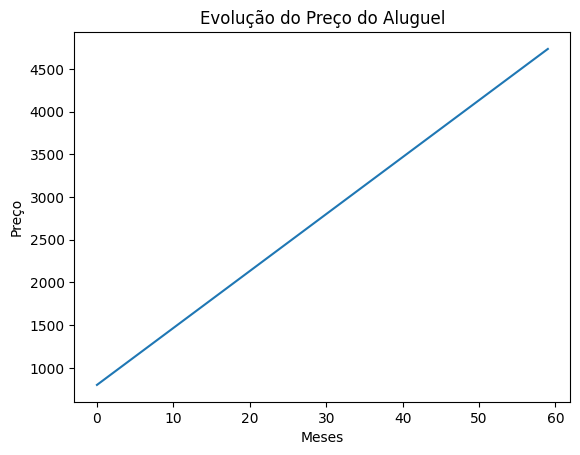

In [13]:
# prompt: plote a serie de valores preco de acordo com os meses

plt.plot(meses, preco)
plt.xlabel('Meses')
plt.ylabel('Preço')
plt.title('Evolução do Preço do Aluguel')
plt.show()
